<a href="https://colab.research.google.com/github/shhjosh02/trabajo-final-sistema-predictivo/blob/main/notebooks/03_LSTM_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Colab conectado. Directorio actual: /content/drive/MyDrive/Proyecto_IA/notebooks

🚀 ENTRENANDO RED NEURONAL LSTM HÍBRIDA (TEXTO + DATOS NUMÉRICOS)
Epoch 1/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9869 - loss: 0.0634 - val_accuracy: 1.0000 - val_loss: 4.2267e-06
Epoch 2/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 2.1358e-07
Epoch 3/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 1.0000 - loss: 7.2887e-04 - val_accuracy: 1.0000 - val_loss: 2.6476e-08
Epoch 4/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 1.0000 - loss: 5.4022e-04 - val_accuracy: 1.0000 - val_loss: 5.3749e-09
Epoch 5/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 1.0000 - loss: 5.5749e-04 - val_accuracy: 1.0000 - val_loss: 1.6102e-09
Epoch 6/25
398/398 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms

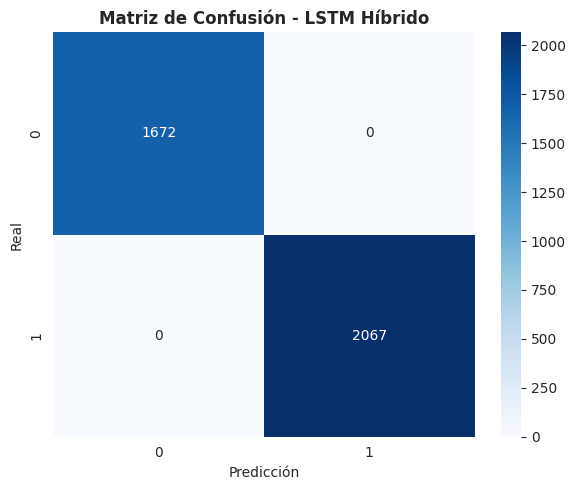


📊 GRÁFICO 2: CURVAS DE APRENDIZAJE (PÉRDIDA Y PRECISIÓN)
📌 QUÉ SE OBSERVA:
• Gráfica de Pérdida (Loss): Evalúa cómo disminuye el error a lo largo de las épocas de entrenamiento.
• Gráfica de Precisión (Accuracy): Muestra la evolución del rendimiento en los datos de entrenamiento y validación.
• Diagnóstico de Sobreajuste (Overfitting): Si la curva de validación se aleja significativamente de la de entrenamiento, indica overfitting. Si ambas convergen juntas, el modelo generaliza correctamente.



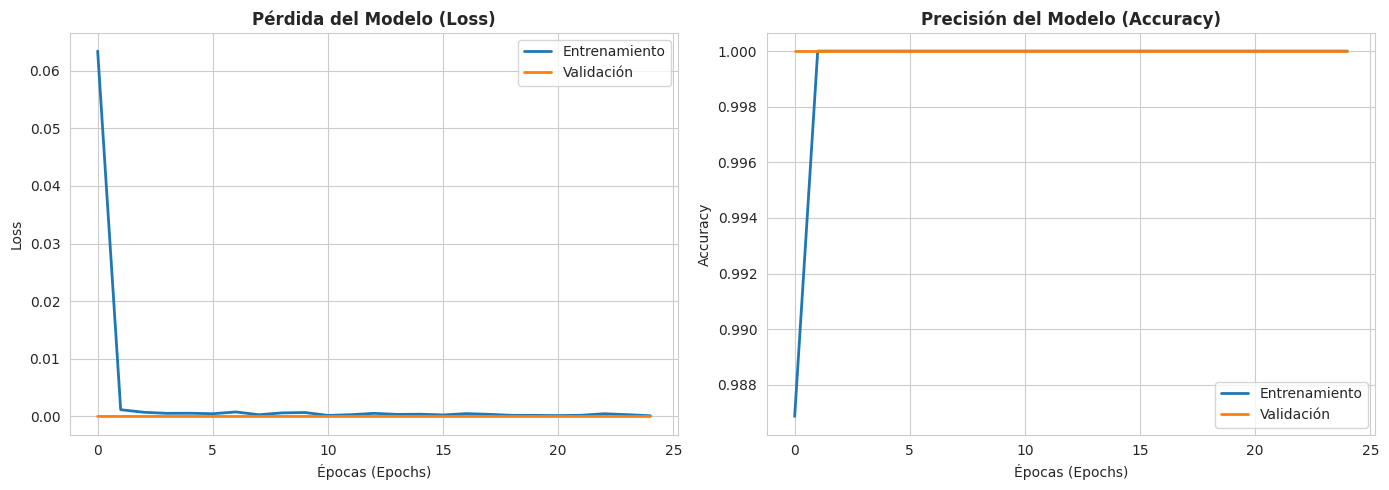


✅ LSTM Ejecutado y Gráficos Generados Exitosamente.


In [2]:
# =========================================================
# BLOQUE DE PORTABILIDAD: Colab + Drive + Local
# =========================================================
import os
import sys

EN_COLAB = 'google.colab' in sys.modules
CARPETA_DRIVE = 'Proyecto_IA'

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir(f'/content/drive/MyDrive/{CARPETA_DRIVE}/notebooks')
    print(f"✅ Colab conectado. Directorio actual: {os.getcwd()}")

os.makedirs('../outputs/graficos', exist_ok=True)

# -*- coding: utf-8 -*-
"""
MODELO LSTM HÍBRIDO CON TENSORFLOW Y EVALUACIÓN GRÁFICA
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, concatenate
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# 2. CARGAR DATOS
df = pd.read_csv('../data/dataset_final_para_modelos(modificado).csv', sep=';', encoding='latin-1')

if 'ï»¿date' in df.columns:
    df.rename(columns={'ï»¿date': 'date'}, inplace=True)

df['daily_return'] = (df['close'] - df['open']) / df['open']
df['intraday_volatility'] = (df['high'] - df['low']) / df['close']
df['volume_scaled'] = df['volume'] / df['volume'].max()
df['price_range'] = df['high'] - df['low']

# 3. PREPARAR TEXTO
headlines = df['Headline_esp'].astype(str).values
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(headlines)
X_text = pad_sequences(tokenizer.texts_to_sequences(headlines), maxlen=20, padding='post', truncating='post')

# 4. NUMÉRICOS Y LABELS
scaler = StandardScaler()
X_num = scaler.fit_transform(df[['daily_return', 'intraday_volatility', 'volume_scaled', 'price_range']].fillna(0).values)
y = df['Label'].values

# 5. DIVIDIR DATOS
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y, test_size=0.2, random_state=42
)

# 6. CONSTRUIR MODELO LSTM HÍBRIDO
text_input = tf.keras.Input(shape=(20,), name='text_input')
x = Embedding(5000, 64)(text_input)
x = LSTM(32)(x)
x = Dropout(0.2)(x)
text_output = Dense(16, activation='relu')(x)

num_input = tf.keras.Input(shape=(4,), name='num_input')
y_net = Dense(16, activation='relu')(num_input)
num_output = Dense(8, activation='relu')(y_net)

combined = concatenate([text_output, num_output])
z = Dense(16, activation='relu')(combined)
z = Dropout(0.2)(z)
output = Dense(1, activation='sigmoid')(z)

model_lstm = tf.keras.Model(inputs=[text_input, num_input], outputs=output)
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. ENTRENAR CON HISTORIAL
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n" + "="*60)
print("🚀 ENTRENANDO RED NEURONAL LSTM HÍBRIDA (TEXTO + DATOS NUMÉRICOS)")
print("="*60)
history = model_lstm.fit(
    [X_text_train, X_num_train], y_train,
    epochs=25, batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop], verbose=1
)

# =========================================================
# 8. GRÁFICO 1: MATRIZ DE CONFUSIÓN DEL LSTM
# =========================================================
print("\n" + "="*75)
print("📊 GRÁFICO 1: MATRIZ DE CONFUSIÓN - LSTM HÍBRIDO")
print("="*75)
print("📌 QUÉ SE OBSERVA:")
print("• Mide la exactitud y los errores específicos de la red LSTM combinando texto y variables financieras.")
print("• Muestra el balance entre predicciones acertadas de tendencias alcistas vs. bajistas.")
print("="*75 + "\n")

y_pred_probs = model_lstm.predict([X_text_test, X_num_test])
y_pred_lstm = (y_pred_probs > 0.5).astype(int).flatten()

plt.figure(figsize=(6, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - LSTM Híbrido', fontsize=12, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('../outputs/graficos/lstm_matriz_confusion.png', dpi=300)
plt.show()

# =========================================================
# 9. GRÁFICO 2: CURVAS DE APRENDIZAJE (PÉRDIDA Y PRECISIÓN)
# =========================================================
print("\n" + "="*75)
print("📊 GRÁFICO 2: CURVAS DE APRENDIZAJE (PÉRDIDA Y PRECISIÓN)")
print("="*75)
print("📌 QUÉ SE OBSERVA:")
print("• Gráfica de Pérdida (Loss): Evalúa cómo disminuye el error a lo largo de las épocas de entrenamiento.")
print("• Gráfica de Precisión (Accuracy): Muestra la evolución del rendimiento en los datos de entrenamiento y validación.")
print("• Diagnóstico de Sobreajuste (Overfitting): Si la curva de validación se aleja significativamente de la de entrenamiento, indica overfitting. Si ambas convergen juntas, el modelo generaliza correctamente.")
print("="*75 + "\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Pérdida
axes[0].plot(history.history['loss'], label='Entrenamiento', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validación', linewidth=2)
axes[0].set_title('Pérdida del Modelo (Loss)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Épocas (Epochs)')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Gráfica de Precisión
axes[1].plot(history.history['accuracy'], label='Entrenamiento', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validación', linewidth=2)
axes[1].set_title('Precisión del Modelo (Accuracy)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Épocas (Epochs)')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/graficos/lstm_curvas_aprendizaje.png', dpi=300)
plt.show()

print("\n✅ LSTM Ejecutado y Gráficos Generados Exitosamente.")